In [17]:
#Import Libraries

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


In [18]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

print("\nDescriptive statistics:")
print(df.describe())


Dataset shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

Descriptive statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:

# 3. Train Gaussian Naive Bayes


nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)


In [21]:
y_pred_nb

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])

In [22]:
y_test

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [23]:

print("\n=== Gaussian Naive Bayes Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))



=== Gaussian Naive Bayes Results ===
Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



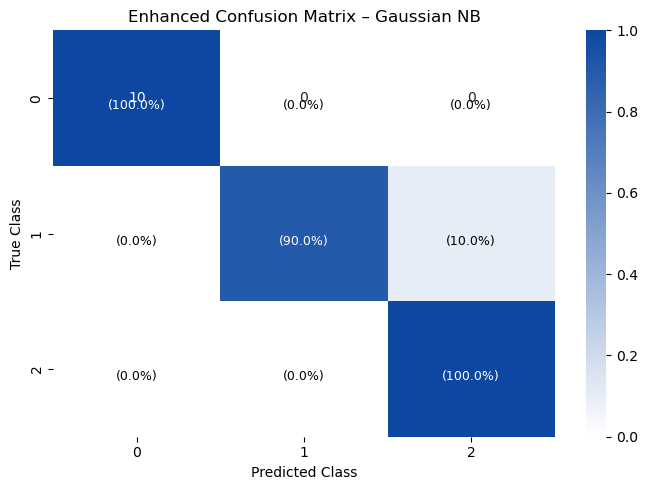

In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_nb)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

# Custom colormap: white for 0, deep blue for max
colors = ["#ffffff", "#0d47a1"]  # white → deep blue
cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

plt.figure(figsize=(7,5))
ax = sns.heatmap(cm_percent, annot=cm, fmt="d", cmap=cmap,
                 xticklabels=[0, 1, 2],
                 yticklabels=[0, 1, 2])

# Add percentage text on top of counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j+0.5, i+0.5, f"\n({cm_percent[i,j]*100:.1f}%)",
                ha="center", va="center", color="black" if cm_percent[i,j]<0.5 else "white", fontsize=9)

plt.title("Enhanced Confusion Matrix – Gaussian NB")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


In [26]:

# 5. Comparison Model: KNN 

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("\n=== KNN Results (k=5) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))



=== KNN Results (k=5) ===
Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



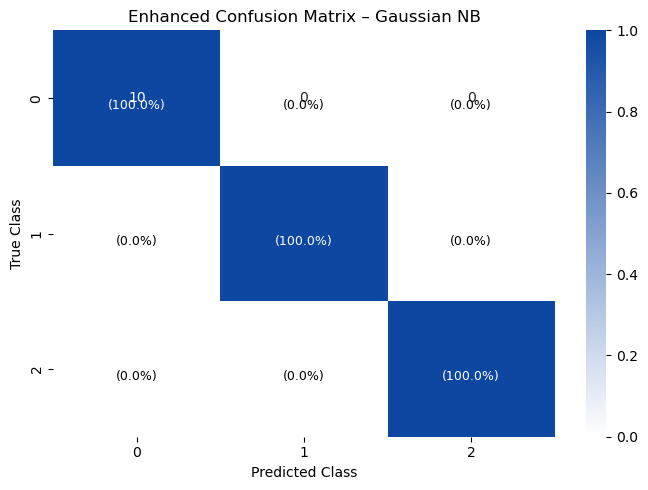

In [28]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)
cm_percent = cm / cm.sum(axis=1, keepdims=True)

# Custom colormap: white for 0, deep blue for max
colors = ["#ffffff", "#0d47a1"]  # white → deep blue
cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

plt.figure(figsize=(7,5))
ax = sns.heatmap(cm_percent, annot=cm, fmt="d", cmap=cmap,
                 xticklabels=[0, 1, 2],
                 yticklabels=[0, 1, 2])

# Add percentage text on top of counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j+0.5, i+0.5, f"\n({cm_percent[i,j]*100:.1f}%)",
                ha="center", va="center", color="black" if cm_percent[i,j]<0.5 else "white", fontsize=9)

plt.title("Enhanced Confusion Matrix – KNN")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()
